In [25]:
import torch
import torch.nn as nn
from transformers import (
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    RobertaModel,
)
from transformers.modeling_outputs import SequenceClassifierOutput

from datasets import Dataset
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime

print("="*70)
print("MULTI-CLASS ROBERTA TRAINING")
print("="*70)

# ============= LOAD CLASS MAPPING =============
print("\n[1/6] Loading class configuration...")

try:
    with open('models/mental_health_roberta/label_mapping.json', 'r') as f:
        label_mapping = json.load(f)
    
    with open('models/mental_health_roberta/class_weights.json', 'r') as f:
        class_weights_dict = json.load(f)
    
    NUM_LABELS = len(label_mapping)
    class_weights = torch.tensor([class_weights_dict[str(i)] for i in range(NUM_LABELS)])
    
    print(f"+ Loaded configuration:")
    print(f"   Number of classes: {NUM_LABELS}")
    print(f"   Classes: {list(label_mapping.keys())}")
    
except Exception as e:
    print(f"? Error loading configuration: {e}")
    exit(1)

# ============= HYBRID DEFINITION =============

class RobertaLSTMCNNClassifier(nn.Module):
    def __init__(
        self,
        model_name: str,
        num_labels: int,
        lstm_hidden: int = 256,
        lstm_layers: int = 1,
        bidirectional: bool = True,
        num_filters: int = 100,
        kernel_sizes=(2, 3, 4),
        dropout: float = 0.3,
    ):
        super().__init__()
        # RoBERTa encoder (same backbone as before)
        self.roberta = RobertaModel.from_pretrained(model_name)
        self.config = self.roberta.config
        hidden_size = self.config.hidden_size  # 768 for roberta-base

        # BiLSTM over token sequence (captures long-range context)
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
        )
        lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)

        # 1D CNN over time (captures local n-gram patterns)
        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=lstm_out_dim,
                out_channels=num_filters,
                kernel_size=k
            )
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(num_filters * len(kernel_sizes), num_labels)


    def forward(self, input_ids, attention_mask=None, labels=None):
        # 1) RoBERTa contextual embeddings
        outputs = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        sequence_output = outputs.last_hidden_state  # (B, T, H)

        # 2) BiLSTM over tokens
        lstm_out, _ = self.lstm(sequence_output)     # (B, T, H_lstm*)

        # 3) CNN + max-over-time on LSTM outputs
        x = lstm_out.transpose(1, 2)                 # (B, C, T)
        conv_feats = []
        for conv in self.convs:
            c = torch.relu(conv(x))                  # (B, F, T')
            c = torch.max(c, dim=2).values           # (B, F)
            conv_feats.append(c)

        features = torch.cat(conv_feats, dim=1)      # (B, F * #kernels)
        features = self.dropout(features)
        logits = self.classifier(features)           # (B, num_labels)

        # Return in HuggingFace format
        return SequenceClassifierOutput(
            logits=logits,
            hidden_states=None,
            attentions=None
        )
    


    def gradient_checkpointing_enable(self, gradient_checkpointing_kwargs=None):
        # Forward to underlying RoBERTa model (HF Trainer expects this)
        if hasattr(self.roberta, "gradient_checkpointing_enable"):
            if gradient_checkpointing_kwargs is not None:
                self.roberta.gradient_checkpointing_enable(
                    gradient_checkpointing_kwargs=gradient_checkpointing_kwargs
                )
            else:
                self.roberta.gradient_checkpointing_enable()
    
    def gradient_checkpointing_disable(self):
        if hasattr(self.roberta, "gradient_checkpointing_disable"):
            self.roberta.gradient_checkpointing_disable()



# ============= CONFIGURATION =============
CONFIG = {
    'model_name': 'FacebookAI/roberta-base',
    'output_dir': './models/mental_health_roberta_hybrid',
    'num_labels': NUM_LABELS,
    'num_epochs': 4,
    'batch_size': 8,
    'gradient_accumulation_steps': 4,
    'learning_rate': 2e-5,
    'warmup_ratio': 0.1,
    'weight_decay': 0.01,
    'max_length': 512,
    'early_stopping_patience': 3,
}

print("\n+ Training Configuration:")
for key, value in CONFIG.items():
    if key != 'model_name':
        print(f"  {key:<30} {value}")

# ============= DEVICE SETUP =============
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n+  Device: {device}")

if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")



MULTI-CLASS ROBERTA TRAINING

[1/6] Loading class configuration...
+ Loaded configuration:
   Number of classes: 7
   Classes: ['Normal', 'Anxiety', 'Depression', 'Stress', 'Suicidal', 'Bipolar', 'Personality disorder']

+ Training Configuration:
  output_dir                     ./models/mental_health_roberta_hybrid
  num_labels                     7
  num_epochs                     4
  batch_size                     8
  gradient_accumulation_steps    4
  learning_rate                  2e-05
  warmup_ratio                   0.1
  weight_decay                   0.01
  max_length                     512
  early_stopping_patience        3

+  Device: cuda
  GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
  Memory: 6.44 GB


In [26]:
# ============= LOAD DATA =============
print("\n[2/6] Loading datasets...")

try:
    train_df = pd.read_csv('data/train.csv')
    val_df = pd.read_csv('data/val.csv')
    
    print(f"+ Train: {len(train_df)} samples")
    print(f"+ Val:   {len(val_df)} samples")
    
    print(f"\n+ Training set class distribution:")
    for class_name, class_idx in sorted(label_mapping.items(), key=lambda x: x[1]):
        count = (train_df['label'] == class_idx).sum()
        print(f"  [{class_idx}] {class_name:<25} {count:>6} samples")
    
    train_dataset = Dataset.from_pandas(train_df)
    val_dataset = Dataset.from_pandas(val_df)
    
except Exception as e:
    print(f"? Error loading data: {e}")
    exit(1)




[2/6] Loading datasets...
+ Train: 35058 samples
+ Val:   7512 samples

+ Training set class distribution:
  [0] Normal                     10716 samples
  [1] Anxiety                     2515 samples
  [2] Depression                 10462 samples
  [3] Stress                      1602 samples
  [4] Suicidal                    7397 samples
  [5] Bipolar                     1744 samples
  [6] Personality disorder         622 samples


In [27]:
# ============= TOKENIZATION =============
print("\n[3/6] Loading tokenizer and tokenizing...")

tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=CONFIG['max_length']
    )

print("Tokenizing datasets...")
train_dataset = train_dataset.map(tokenize_function, batched=True, remove_columns=['text'])
val_dataset = val_dataset.map(tokenize_function, batched=True, remove_columns=['text'])
print("+ Tokenization complete")




[3/6] Loading tokenizer and tokenizing...
Tokenizing datasets...


Map:   0%|          | 0/35058 [00:00<?, ? examples/s]

Map:   0%|          | 0/7512 [00:00<?, ? examples/s]

+ Tokenization complete


In [28]:
# ============= MODEL INITIALIZATION =============
print(f"\n[4/6] Loading model (RoBERTa + LSTM-CNN hybrid): {CONFIG['model_name']}\n")

model = RobertaLSTMCNNClassifier(
    model_name=CONFIG['model_name'],
    num_labels=CONFIG['num_labels'],
    lstm_hidden=256,          # you can tune 128/256/384
    lstm_layers=1,
    bidirectional=True,
    num_filters=100,          # filters per kernel size
    kernel_sizes=(2, 3, 4),   # bi-gram, tri-gram, 4-gram
    dropout=0.3
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"+ Hybrid model loaded: {num_params / 1e6:.1f}M parameters")


# ============= CUSTOM TRAINER WITH LOGITS ACCEPTANCE =============
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        
        # Extract logits (works with both dict-like and ModelOutput objects)
        if hasattr(outputs, "logits"):
            logits = outputs.logits
        elif isinstance(outputs, dict):
            logits = outputs["logits"]
        else:
            logits = outputs

        if self.class_weights is not None:
            loss_fct = torch.nn.CrossEntropyLoss(
                weight=self.class_weights.to(logits.device)
            )
        else:
            loss_fct = torch.nn.CrossEntropyLoss()

        loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss



# ============= METRICS =============
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0
    )
    
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )
    
    precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
        labels, predictions, average=None, zero_division=0
    )
    
    metrics = {
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
    }
    
    class_names = [k for k, v in sorted(label_mapping.items(), key=lambda x: x[1])]
    for i, class_name in enumerate(class_names):
        metrics[f'f1_{class_name.lower().replace(" ", "_").replace("-", "_")}'] = f1_per_class[i]
    
    return metrics




[4/6] Loading model (RoBERTa + LSTM-CNN hybrid): FacebookAI/roberta-base



Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


+ Hybrid model loaded: 127.2M parameters


In [29]:
# ============= TRAINING SETUP =============
print("\n[5/6] Setting up training...")

os.makedirs(CONFIG['output_dir'], exist_ok=True)
os.makedirs('results', exist_ok=True)

training_args = TrainingArguments(
    output_dir=CONFIG['output_dir'],
    num_train_epochs=CONFIG['num_epochs'],
    per_device_train_batch_size=CONFIG['batch_size'],
    per_device_eval_batch_size=CONFIG['batch_size'] * 2,
    gradient_accumulation_steps=CONFIG['gradient_accumulation_steps'],
    learning_rate=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay'],
    warmup_ratio=CONFIG['warmup_ratio'],
    
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    
    logging_dir='./logs',
    logging_steps=50,
    logging_first_step=True,
    report_to="none",
    
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    optim="adamw_torch",
    
    save_total_limit=2,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=CONFIG['early_stopping_patience'])],
    class_weights=class_weights
)

print("+ Using weighted loss for class imbalance")



warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



[5/6] Setting up training...
+ Using weighted loss for class imbalance


In [30]:
# ============= TRAINING =============
print("\n[6/6] Starting training...")
print("="*70)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

training_start = datetime.now()

try:
    train_result = trainer.train()
    training_end = datetime.now()
    training_duration = (training_end - training_start).total_seconds() / 60
    
    print("\n" + "="*70)
    print("+ TRAINING COMPLETE")
    print("="*70)
    print(f"Duration: {training_duration:.2f} minutes ({training_duration/60:.2f} hours)")
    
except KeyboardInterrupt:
    print("\n?  Training interrupted")
    training_end = datetime.now()
    training_duration = (training_end - training_start).total_seconds() / 60
except Exception as e:
    print(f"\n? Training failed: {e}")
    import traceback
    traceback.print_exc()
    exit(1)

# ============= SAVE MODEL =============
print(f"\n+ Saving model...")

trainer.save_model(CONFIG['output_dir'])
tokenizer.save_pretrained(CONFIG['output_dir'])
print("+ Model saved")

# ============= FINAL VALIDATION =============
print("\n+ Running final validation...")

val_results = trainer.evaluate()

print("\n" + "="*70)
print("FINAL VALIDATION METRICS")
print("="*70)
print(f"{'Accuracy:':<30} {val_results['eval_accuracy']:.4f}")
print(f"{'F1 (Macro):':<30} {val_results['eval_f1_macro']:.4f}")
print(f"{'F1 (Weighted):':<30} {val_results['eval_f1_weighted']:.4f}")

print("\n+ Per-Class F1 Scores:")
class_names = [k for k, v in sorted(label_mapping.items(), key=lambda x: x[1])]
for class_name in class_names:
    key = f'eval_f1_{class_name.lower().replace(" ", "_").replace("-", "_")}'
    if key in val_results:
        f1 = val_results[key]
        bar = '*' * int(f1 * 50)
        print(f"  {class_name:<25} {f1:.4f} {bar}")

# ============= SAVE RESULTS =============
training_log = {
    'model_name': CONFIG['model_name'],
    'num_labels': CONFIG['num_labels'],
    'classes': list(label_mapping.keys()),
    'training_duration_minutes': training_duration,
    'final_metrics': {
        k.replace('eval_', ''): float(v) if isinstance(v, (np.floating, float)) else v 
        for k, v in val_results.items()
    }
}

with open('results/training_log.json', 'w') as f:
    json.dump(training_log, f, indent=2)

print("\n+ Saved: results/training_log.json")




[6/6] Starting training...
Start time: 2026-02-17 17:39:38


Step,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted,F1 Normal,F1 Anxiety,F1 Depression,F1 Stress,F1 Suicidal,F1 Bipolar,F1 Personality Disorder
200,1.723146,1.670565,0.600373,0.363777,0.406178,0.378004,0.562343,0.600373,0.575198,0.843398,0.500000,0.534021,0.000000,0.520846,0.247761,0.000000
400,0.998951,0.916004,0.772897,0.704479,0.697866,0.694658,0.776461,0.772897,0.772089,0.925184,0.817658,0.725972,0.512821,0.689013,0.751592,0.440367
600,0.703733,0.691698,0.787007,0.718198,0.765691,0.725013,0.800296,0.787007,0.789778,0.933711,0.860902,0.758292,0.620178,0.665966,0.798928,0.437113
800,0.587233,0.616718,0.808440,0.775046,0.783457,0.769966,0.821317,0.808440,0.811587,0.931844,0.868722,0.765541,0.626768,0.733681,0.830725,0.632479
1000,0.603016,0.572307,0.803115,0.774486,0.805193,0.774575,0.831543,0.803115,0.808741,0.926763,0.835759,0.751836,0.628231,0.749718,0.847125,0.682594
1200,0.442524,0.535679,0.815495,0.795452,0.814022,0.793703,0.842384,0.815495,0.812595,0.952300,0.897004,0.709309,0.739970,0.745332,0.862162,0.649842
1400,0.548847,0.482701,0.819755,0.764071,0.829198,0.790736,0.829525,0.819755,0.819673,0.945359,0.860606,0.752115,0.755927,0.750218,0.800000,0.670927
1600,0.469910,0.501287,0.822284,0.787965,0.828619,0.799212,0.844865,0.822284,0.822066,0.947138,0.888046,0.741284,0.750353,0.756714,0.840102,0.670846
1800,0.441066,0.473137,0.821885,0.763677,0.836733,0.788932,0.839873,0.821885,0.825453,0.934137,0.886792,0.777371,0.674493,0.759011,0.840880,0.649842
2000,0.468564,0.463484,0.799920,0.785382,0.833137,0.791316,0.849069,0.799920,0.796483,0.943795,0.889686,0.668392,0.754950,0.738304,0.844784,0.699301



+ TRAINING COMPLETE
Duration: 156.15 minutes (2.60 hours)

+ Saving model...
+ Model saved

+ Running final validation...



FINAL VALIDATION METRICS
Accuracy:                      0.8478
F1 (Macro):                    0.8303
F1 (Weighted):                 0.8475

+ Per-Class F1 Scores:
  Normal                    0.9567 ***********************************************
  Anxiety                   0.8907 ********************************************
  Depression                0.7890 ***************************************
  Stress                    0.7934 ***************************************
  Suicidal                  0.7713 **************************************
  Bipolar                   0.8791 *******************************************
  Personality disorder      0.7321 ************************************

+ Saved: results/training_log.json


+ Saved: results/training_curves.png


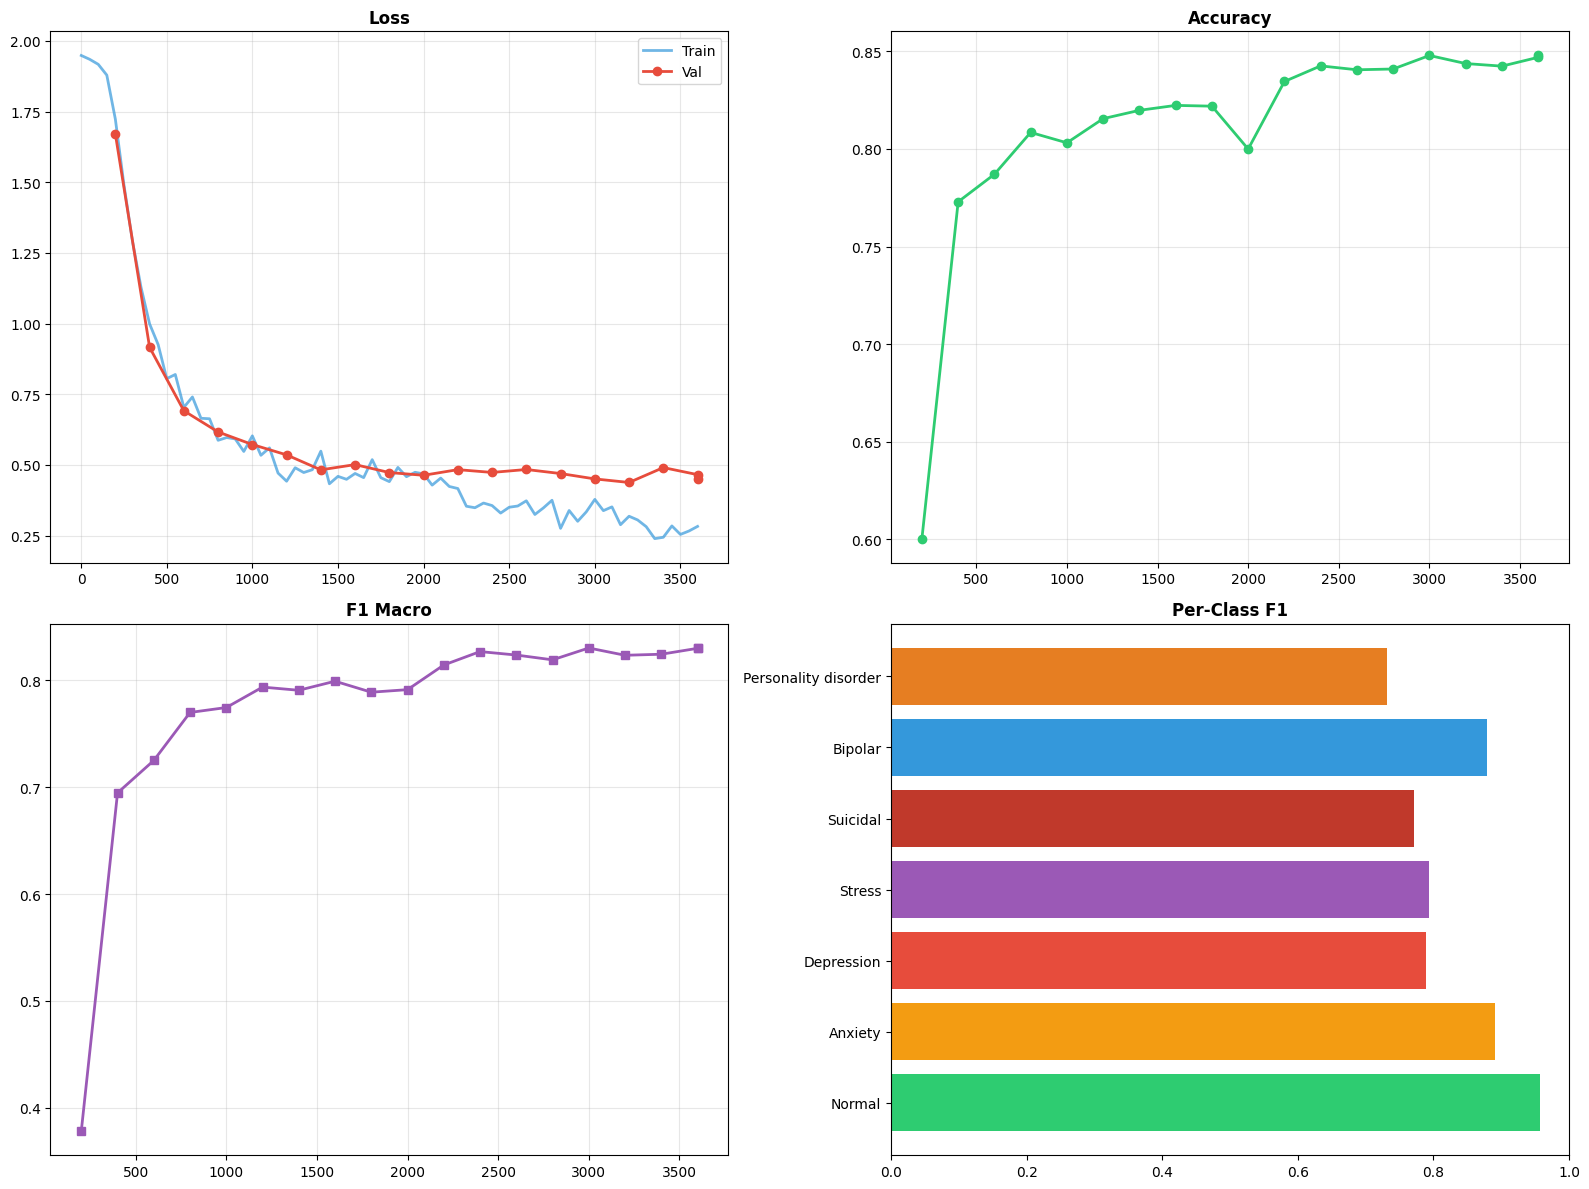

In [31]:
# ============= TRAINING CURVES =============
log_history = trainer.state.log_history

train_loss = [x['loss'] for x in log_history if 'loss' in x]
train_steps = [x['step'] for x in log_history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
eval_acc = [x['eval_accuracy'] for x in log_history if 'eval_accuracy' in x]
eval_f1_macro = [x['eval_f1_macro'] for x in log_history if 'eval_f1_macro' in x]
eval_steps = [x['step'] for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(train_steps, train_loss, label='Train', linewidth=2, color='#3498db', alpha=0.7)
axes[0, 0].plot(eval_steps, eval_loss, label='Val', linewidth=2, color='#e74c3c', marker='o')
axes[0, 0].set_title('Loss', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(eval_steps, eval_acc, linewidth=2, color='#2ecc71', marker='o')
axes[0, 1].set_title('Accuracy', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(eval_steps, eval_f1_macro, linewidth=2, color='#9b59b6', marker='s')
axes[1, 0].set_title('F1 Macro', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

class_f1 = [val_results.get(f'eval_f1_{c.lower().replace(" ","_").replace("-","_")}', 0) for c in class_names]
axes[1, 1].barh(class_names, class_f1, color=['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#c0392b', '#3498db', '#e67e22'])
axes[1, 1].set_title('Per-Class F1', fontweight='bold')
axes[1, 1].set_xlim([0, 1])

plt.tight_layout()
plt.savefig('results/training_curves.png', dpi=300, bbox_inches='tight')
print("+ Saved: results/training_curves.png")
